In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/AnnaShestova/salary-years-simple-linear-regression/master/Salary_Data.csv"
df4 = pd.read_csv(url)
df4.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
df4.info()
print(df4.shape)
print(df4.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
(30, 2)
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


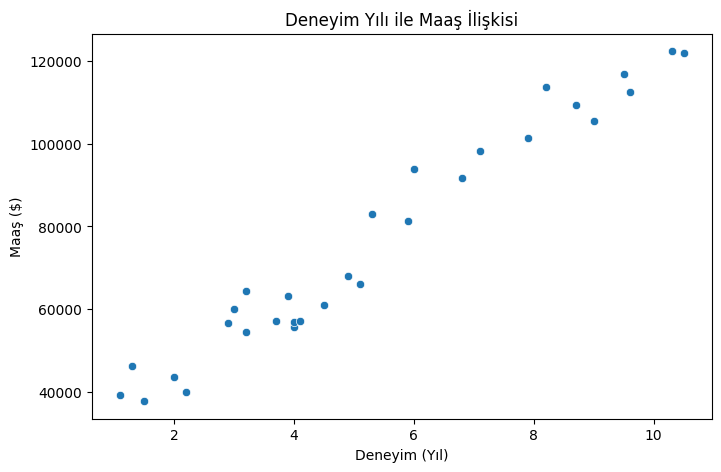

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df4, x="YearsExperience", y="Salary")
plt.title("Deneyim Yılı ile Maaş İlişkisi")
plt.xlabel("Deneyim (Yıl)")
plt.ylabel("Maaş ($)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X5 = df4[["YearsExperience"]]
y5 = df4["Salary"]

X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

model_maas = LinearRegression()
model_maas.fit(X5_train, y5_train)

print("Katsayı:", model_maas.coef_)
print("Sabit terim:", model_maas.intercept_)

Katsayı: [9423.81532303]
Sabit terim: 25321.583011776813


In [ ]:
tahmin_maas = model_maas.predict(X5_test)

mae_maas = mean_absolute_error(y5_test, tahmin_maas)
r2_maas = r2_score(y5_test, tahmin_maas)

print("MAE:", mae_maas)
print("R²:", r2_maas)

MAE: 6286.453830757749
R²: 0.9024461774180497


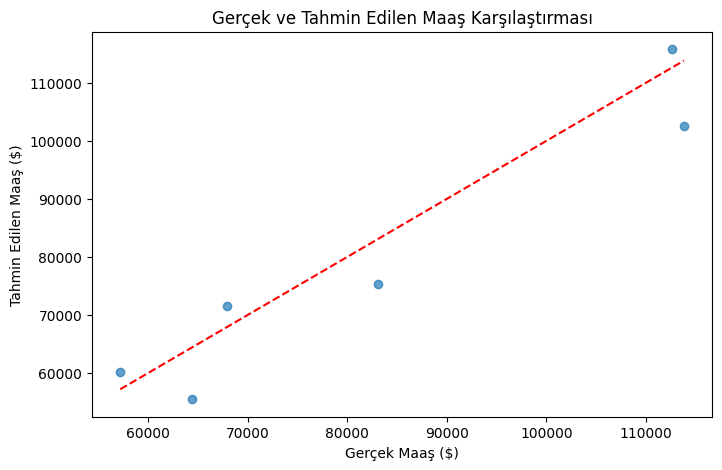

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y5_test, tahmin_maas, alpha=0.7)
plt.plot([y5_test.min(), y5_test.max()], [y5_test.min(), y5_test.max()], color="red", linestyle="--")
plt.xlabel("Gerçek Maaş ($)")
plt.ylabel("Tahmin Edilen Maaş ($)")
plt.title("Gerçek ve Tahmin Edilen Maaş Karşılaştırması")
plt.show()

In [ ]:
ornek_deneyim = pd.DataFrame([[5]], columns=["YearsExperience"])
tahmin = model_maas.predict(ornek_deneyim)

print("5 yıllık deneyim için tahmini maaş:", tahmin[0])

5 yıllık deneyim için tahmini maaş: 72440.6596269317
